|01.2026|
|--------------------------------------------:|

# Bioinformatyka 2 RNA ćwiczenie 2
Maks. 20pkt -> 4pkt

## miRNAs, struktura RNA, gramatyka

#### Zadanie 1 (3pkt)
Dla podanej sekwencji pre-miRNA:
<div style="font-family: 'Courier New', Courier, monospace;">
>pre-mirna <br>
CUUUUAAAUUCUGUUGCAGCAGAUAGCUGAUACCCAAUGUUAUCUUUUGCGGCAGAAAUUGAAAG
</div>

1. Podaj identyfikatory miRNAs pochodzących z tej sekwencji, jaki to gatunek? Wykorzystaj bazę miRBase

- MIMAT0000996
- MIMAT0000997

1. Jakie jednostki chorobowe u człowieka są powiązane z nimi?

- Mononukleoza zakaźna
- Chłoniak
- Ziarnica złośliwa

1. Podaj identyfikatory potencjalnych regulowanych genów (człowiek) (miRTarBase)

- 

#### Zadanie 2 (2pkt)
Dla podanej macierzy kropkowej podaj odpowiadającą strukturę w formacie Vienna:

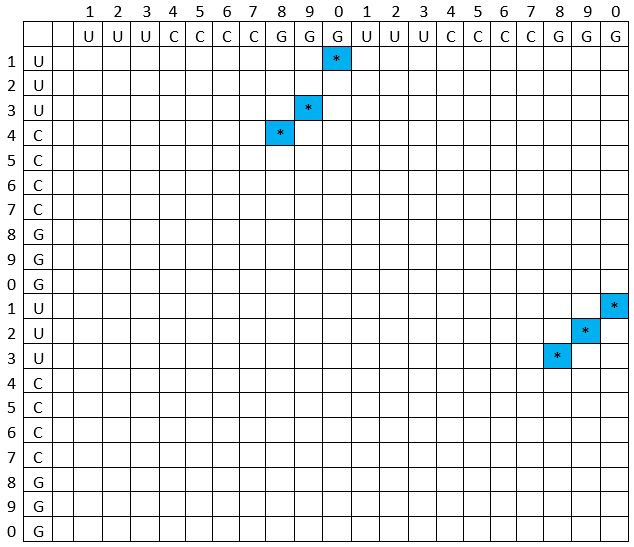

### Zadanie 3. (4pkt)
Używając podanej sekwencji RNA: 
<div style="font-family: 'Courier New', Courier, monospace;">
    GGGCCCAUAGCUCAGUGGUAGAGUGCCUCCUUUGCAAGGAGGAUGCCCUGGGUUCGAAUCCCAGUGGGUCCA
</div>

1. Zidentyfikować cząsteczkę w bazie RFAM (wyszukiwanie „po sekwencji”), podać jakiego typu jest to cząsteczka oraz podać jej strukturę drugorzędową w formacie Vienna oraz w reprezentacji planarnej.
2. Zrealizować trzy różne predykcje: [Nussinov](https://rna.informatik.uni-freiburg.de/Teaching/index.jsp?toolName=Nussinov), MFE ([RNAfold](http://rna.tbi.univie.ac.at/cgi-bin/RNAWebSuite/RNAfold.cgi)), [CentroidFold](http://rtools.cbrc.jp/centroidfold/)
3. Dla każdej predykcji odczytać liczbę wiązań wodorowych i energię swobodną cząsteczki. Energie struktur z Nussinov i CentroidFold oszacować programem [RNAeval](http://rna.tbi.univie.ac.at/cgi-bin/RNAWebSuite/RNAeval.cgi)
4. Wskazać poprawną predykcję i podać jej uzasadnienie, komentując każdy zastosowany algorytm

| Nussinov | RNAfold | CentroidFold | Referencja |
| :-: | :-: | :-: | :-: |
| struktura | struktura | struktura | struktura |
| l. wiązań=|l. wiązań=|l. wiązań=|l. wiązań=|
| en. swobodna [kcal/mol]= | en. swobodna [kcal/mol]= | en. swobodna [kcal/mol]= | en. swobodna [kcal/mol]= |


## Gramatyka generatywna Chomskiego

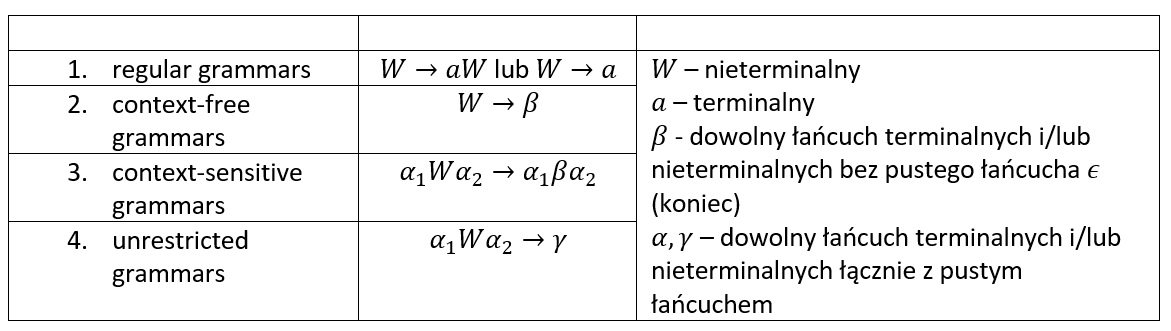


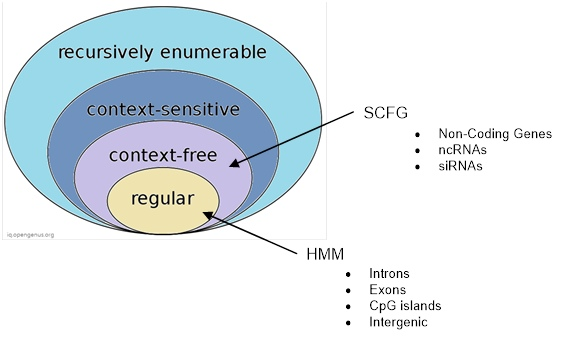

Przykład:

Gramatyka dla łańcucha o nieparzystej liczbie znaku
$$
S \to aW|bS\\
W \to aS|bW|\epsilon
$$
Który symbol będzię występował nieparzystą liczbę razy?

In [19]:
import nltk
#from nltk.grammar import CFG
from nltk.parse.generate import generate
grammar = nltk.CFG.fromstring("""
S -> A W | B S
W -> A S | B W |
A -> 'a'
B -> 'b'
""")
print(grammar)
# help(generate)
print(list(generate(grammar, n = 5,depth = 5))) # Generates an iterator of all sentences from a CFG


Grammar with 7 productions (start state = S)
    S -> A W
    S -> B S
    W -> A S
    W -> B W
    W -> 
    A -> 'a'
    B -> 'b'
[['a', 'a', 'a'], ['a', 'b', 'b'], ['a', 'b'], ['a'], ['b', 'a', 'b']]


Przykład:<br>
Gen **FMR-1** zawiera repetywny region gdzie występują powtórzenia tripletu $cgg$. Liczba tych powtórzeń jest charakterystyczna osobniczo (różnorodna). Przykładowy region:

In [ ]:
... gcg cgg cgg cgg cgg cgg cgg cgg cgg
cgg cgg agg cgg cgg cgg cgg cgg cgg cgg
cgg cgg agg cgg cgg cgg cgg cgg cgg cgg
cgg ctg ...

Utwórzmy gramatykę regularną (?)
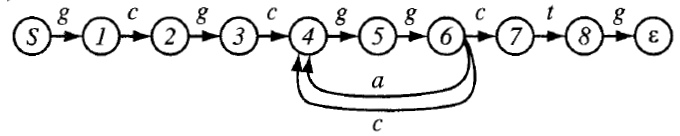

In [24]:
import nltk
#from nltk.grammar import CFG
from nltk.parse.generate import generate
grammar = nltk.CFG.fromstring("""
S -> G W1
W1 -> C W2
W2 -> G W3
W3 -> C W4
W4 -> G W5
W5 -> G W6
W6 -> C W7 | A W4 | C W4
W7 -> T W8
W8 -> G
A -> 'a'
C -> 'c'
G -> 'g'
T -> 't'
""")
print(grammar)
list(generate(grammar, n=4, depth = 15)) # Generates an iterator of all sentences from a CFG

Grammar with 15 productions (start state = S)
    S -> G W1
    W1 -> C W2
    W2 -> G W3
    W3 -> C W4
    W4 -> G W5
    W5 -> G W6
    W6 -> C W7
    W6 -> A W4
    W6 -> C W4
    W7 -> T W8
    W8 -> G
    A -> 'a'
    C -> 'c'
    G -> 'g'
    T -> 't'


[['g', 'c', 'g', 'c', 'g', 'g', 'c', 't', 'g'],
 ['g', 'c', 'g', 'c', 'g', 'g', 'a', 'g', 'g', 'c', 't', 'g'],
 ['g', 'c', 'g', 'c', 'g', 'g', 'c', 'g', 'g', 'c', 't', 'g']]

#### Dopasowywanie sekwencji
Rozważmy sekwencje: 'gcgcggctg'

In [11]:
sent = list('gcgcggctg')
#sent = list('gcgcggcggcggcggcggcggcggcggcggcggaggcggcggcggcggcggcggcggcggcggaggcggcggcggcggcggcggcggcggctg')

#czy symbole terminals z danej sekwencji występuja w grametyce?
print('Coverage of input terminals by a grammar:')
try:
    grammar.check_coverage(sent)
    print("All words covered")
except:
    print("Strange")

#czy sekwencja pochodzi z gramatyki
# parsowanie czyli drzewo dla sekwencji (token)
parser = nltk.ChartParser(grammar)
for tree in parser.parse(sent):
    print(tree)


Coverage of input terminals by a grammar:
All words covered
(S
  (G g)
  (W1
    (C c)
    (W2
      (G g)
      (W3
        (C c)
        (W4 (G g) (W5 (G g) (W6 (C c) (W7 (T t) (W8 (G g))))))))))


### Zadanie 4 (4pkt)
Dla fragmentu motywu Prosite PS00024:

[LIFAT]-{IL}-x(2)-W-x(2,3)-[PE]

zaproponuj reguły produkcji. 

Sprawdź czy uzyskana gramatyka potrafi wygenerować (parse) sekwencje:

1. <div style="font-family: 'Courier New', Courier, monospace;">iadkwpalp</div>
2. <div style="font-family: 'Courier New', Courier, monospace;">iadkwplp</div>
3. <div style="font-family: 'Courier New', Courier, monospace;">amfewpe</div>
4. <div style="font-family: 'Courier New', Courier, monospace;">tqrewgrlp</div>


### Context free grammar 

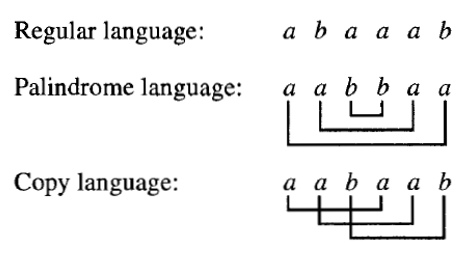

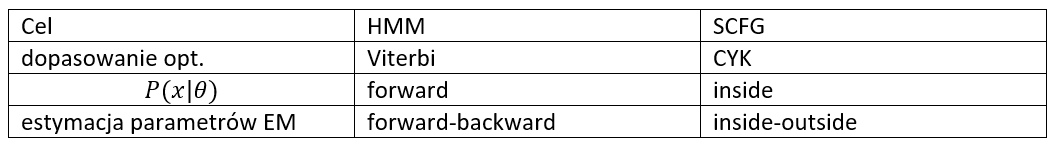

Przykład: <br>
Gramatyka dla palindromu:

$$
S\to aSa\,|\,bSb\,|\,aa\,|\,bb
$$

In [88]:
import nltk
#from nltk.grammar import CFG
from nltk.parse.generate import generate
grammar = nltk.CFG.fromstring("""
S -> A S A | B S B | A A | B B
A -> 'a'
B -> 'b'
""")

list(generate(grammar, n = 15, depth = 5)) # Generates an iterator of all sentences from a CFG

[['a', 'a', 'a', 'a', 'a', 'a'],
 ['a', 'a', 'b', 'b', 'a', 'a'],
 ['a', 'b', 'a', 'a', 'b', 'a'],
 ['a', 'b', 'b', 'b', 'b', 'a'],
 ['a', 'a', 'a', 'a'],
 ['a', 'b', 'b', 'a'],
 ['b', 'a', 'a', 'a', 'a', 'b'],
 ['b', 'a', 'b', 'b', 'a', 'b'],
 ['b', 'b', 'a', 'a', 'b', 'b'],
 ['b', 'b', 'b', 'b', 'b', 'b'],
 ['b', 'a', 'a', 'b'],
 ['b', 'b', 'b', 'b'],
 ['a', 'a'],
 ['b', 'b']]

Gramatyka dla palindromu nukleotydowego
$$
S \to aSu \,|\,uSa\,|\,gSc\,|\,cSg
$$

Dla pełnej struktury II rzędowej (bez pseudowęzłów) wyróżniamy cztery typu produkcji:
1. $S \to xSx$               - para zasad (helisa)
2. $S \to xS$ lub $S \to x$  - niesparowana zasada
3. $S \to S$                 - delecja (skip production)
4. $S \to SS$                - rozgałęzienie

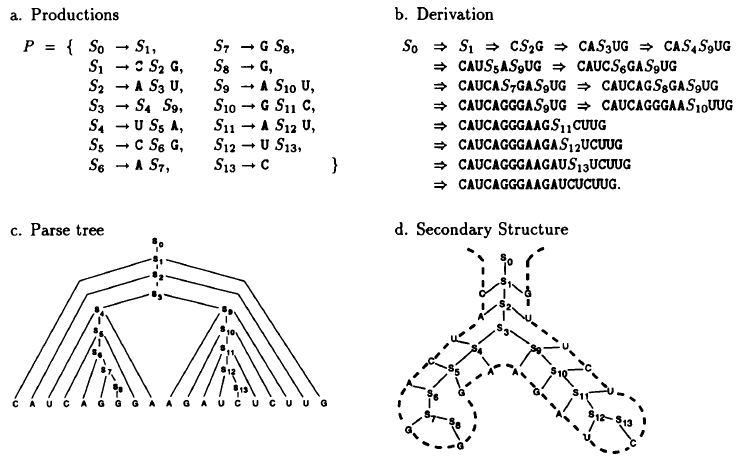

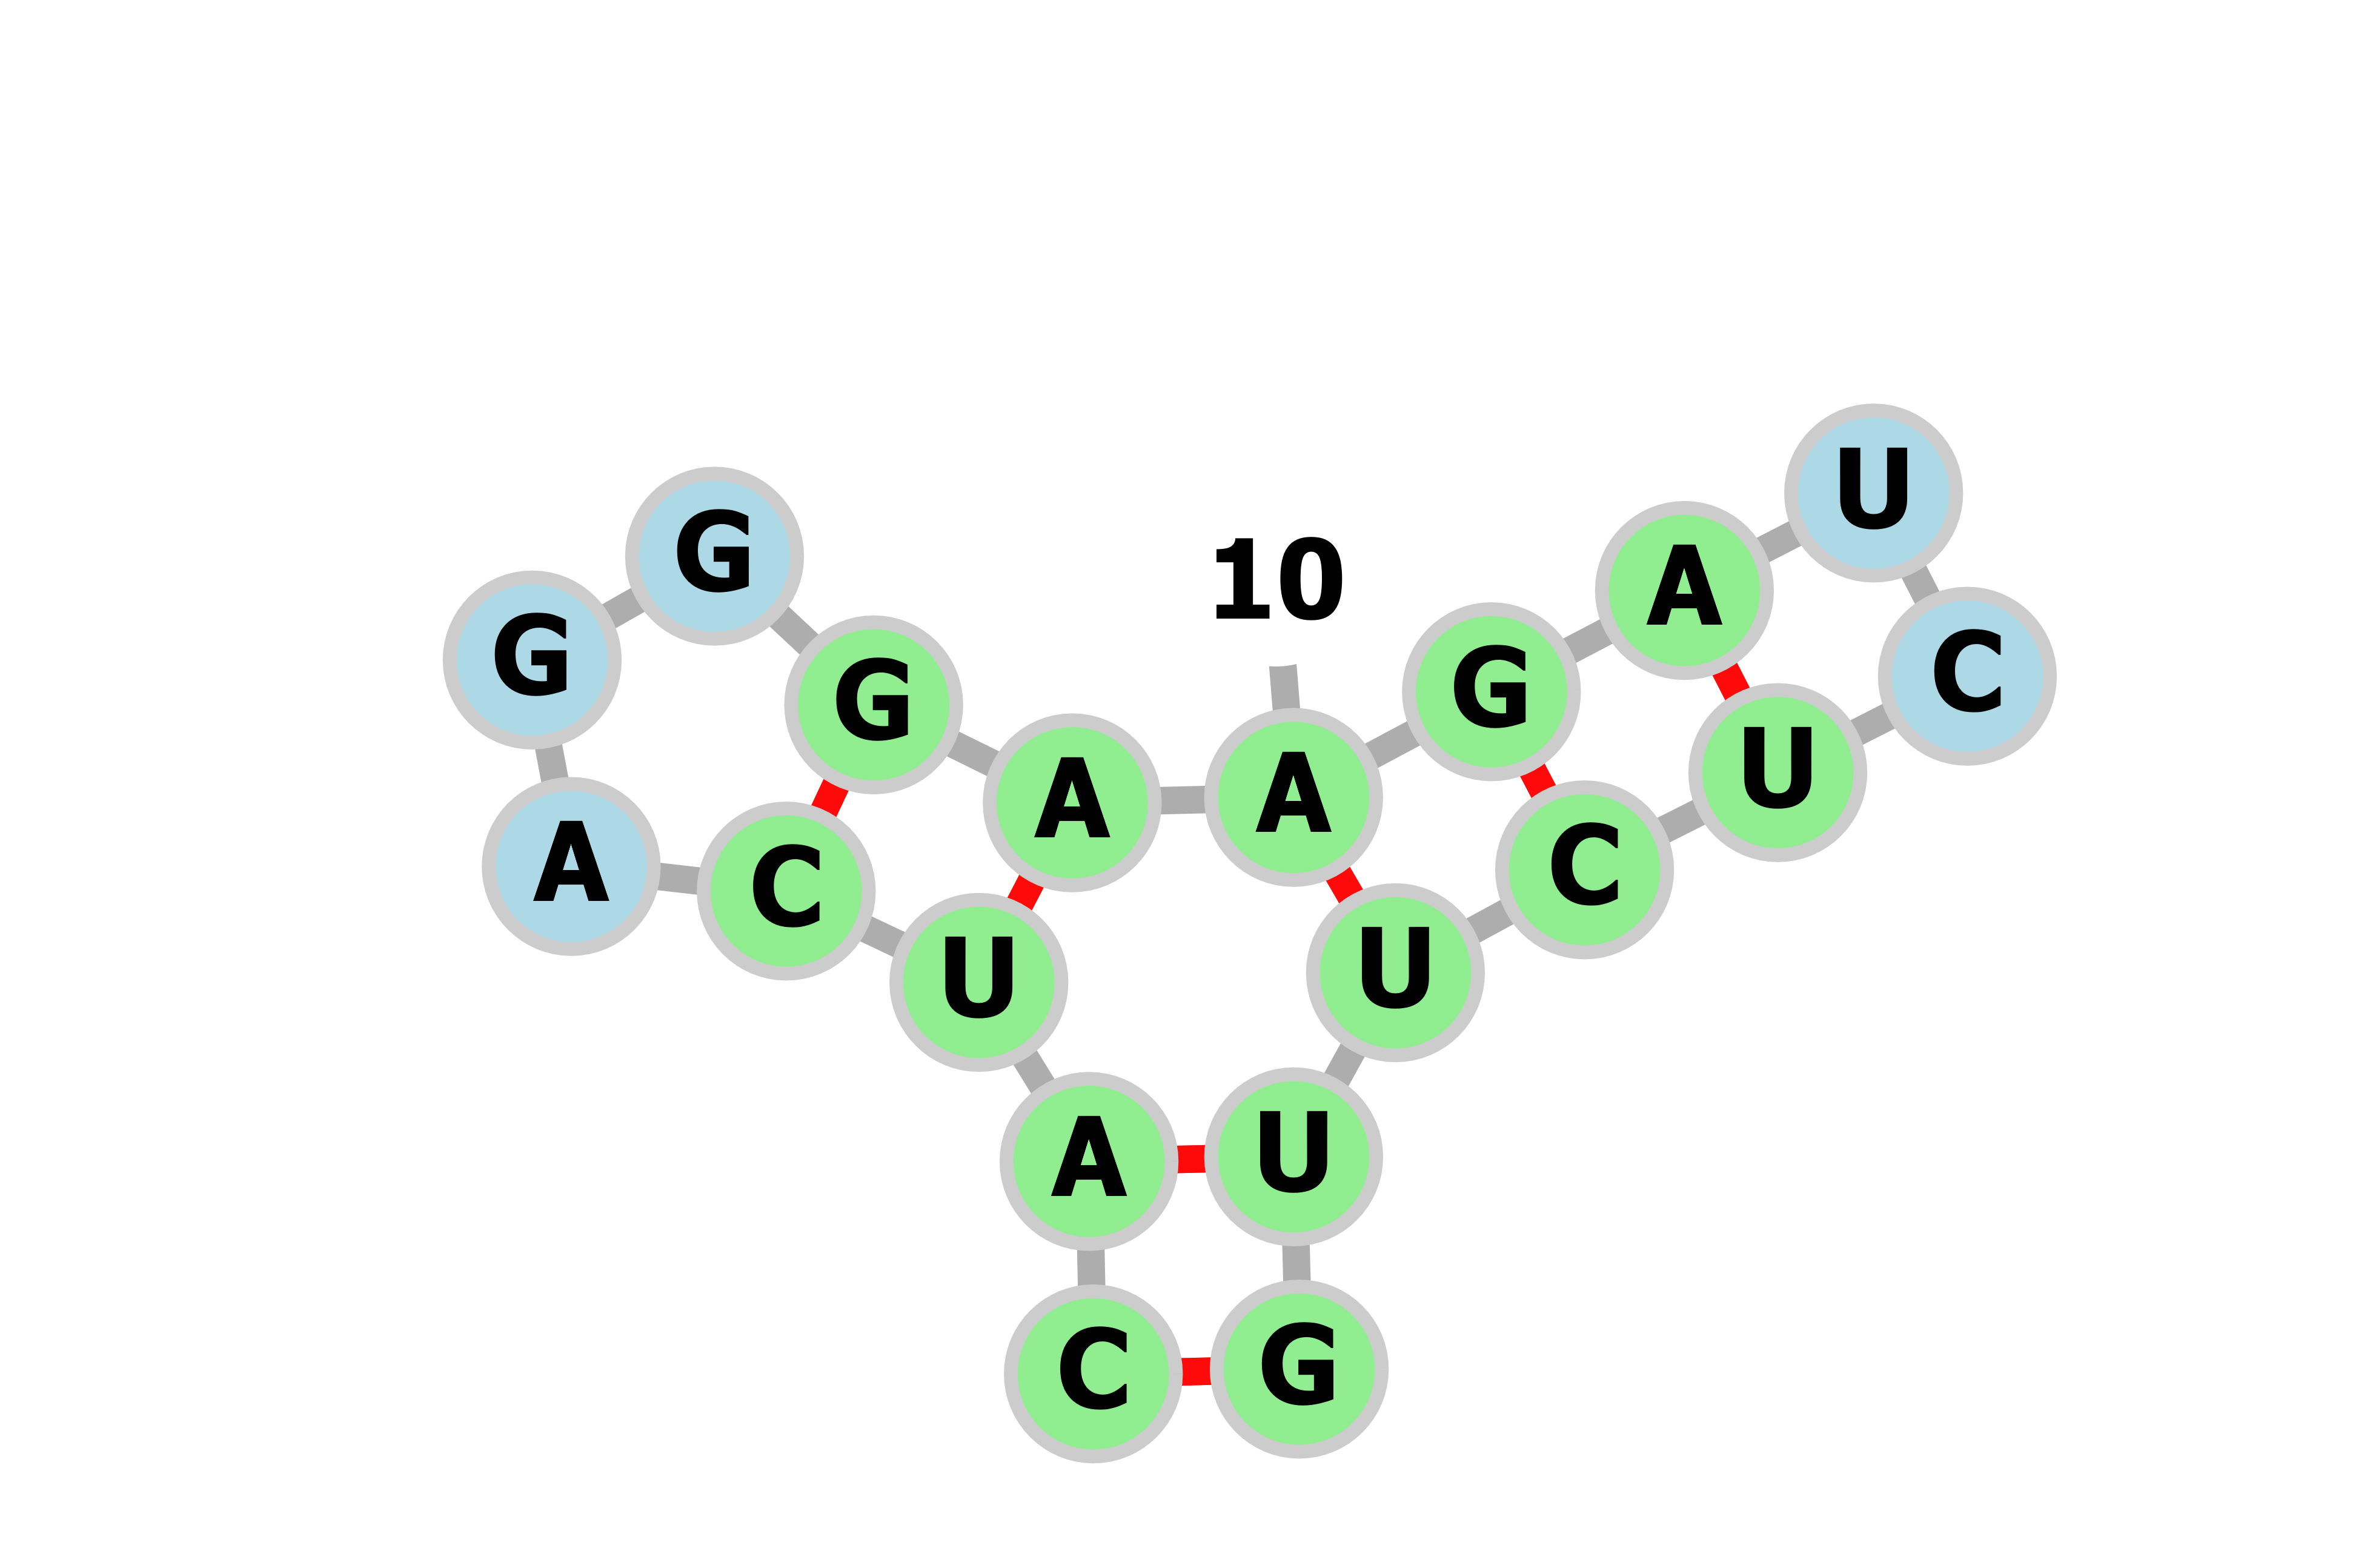

### Probabilistyczna gramatyka bezkontekstowa (PCFG)

Probabilistyczny model dotyczy każdego poziomu gramatyki generatywnej ($\theta$). Prawdopodobieństwo wygenerowania sekwencji $x$:
$$
P(x|\theta)\\
$$

$$
\sum_{x} P(x|\theta) = 1
$$


#### Przykład
Pary Wobble G-U występują w helisach RNA ale z mniejszą częstotliwością niż pary Watson-Crick. Proszę przerobić podaną gramatykę (CFG) w SCFG, ustalając prawdopodobieństwo jako połowę prawdopodobieństwa pary C-G lub A-U.

In [45]:
import nltk
#from nltk.grammar import CFG
from nltk.parse.generate import generate
grammar = nltk.CFG.fromstring("""
S -> A W1 U | C W1 G | G W1 C | U W1 A
W1 -> A W2 U | C W2 G | G W2 C | U W2 A
W2 -> A W3 U | C W3 G | G W3 C | U W3 A
W3 -> G A A A | G C A A
A -> 'a'
C -> 'c'
G -> 'g'
U -> 'u'
""")

list(generate(grammar, n = 10, depth = 6))

[['a', 'a', 'a', 'g', 'a', 'a', 'a', 'u', 'u', 'u'],
 ['a', 'a', 'a', 'g', 'c', 'a', 'a', 'u', 'u', 'u'],
 ['a', 'a', 'c', 'g', 'a', 'a', 'a', 'g', 'u', 'u'],
 ['a', 'a', 'c', 'g', 'c', 'a', 'a', 'g', 'u', 'u'],
 ['a', 'a', 'g', 'g', 'a', 'a', 'a', 'c', 'u', 'u'],
 ['a', 'a', 'g', 'g', 'c', 'a', 'a', 'c', 'u', 'u'],
 ['a', 'a', 'u', 'g', 'a', 'a', 'a', 'a', 'u', 'u'],
 ['a', 'a', 'u', 'g', 'c', 'a', 'a', 'a', 'u', 'u'],
 ['a', 'c', 'a', 'g', 'a', 'a', 'a', 'u', 'g', 'u'],
 ['a', 'c', 'a', 'g', 'c', 'a', 'a', 'u', 'g', 'u']]

In [22]:
from nltk import PCFG
from nltk.parse.generate import generate
pgrammar = PCFG.fromstring("""
S -> A S2 U [0.2]| C S2 G [0.2]| G S2 C [0.2]| U S2 A [0.2] | G S2 U [0.1]| U S2 G [0.1]
S2 -> A S3 U [0.2]| C S3 G [0.2]| G S3 C [0.2]| U S3 A [0.2] | G S3 U [0.1]| U S3 G [0.1]
S3 -> A S4 U [0.2]| C S4 G [0.2]| G S4 C [0.2]| U S4 A [0.2] | G S4 U [0.1]| U S4 G [0.1]
S4 -> G A A A [0.5]| G C A A [0.5]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")

print(pgrammar)
print(list(generate(pgrammar, n = 2, depth = 10)))


Grammar with 24 productions (start state = S)
    S -> A S2 U [0.2]
    S -> C S2 G [0.2]
    S -> G S2 C [0.2]
    S -> U S2 A [0.2]
    S -> G S2 U [0.1]
    S -> U S2 G [0.1]
    S2 -> A S3 U [0.2]
    S2 -> C S3 G [0.2]
    S2 -> G S3 C [0.2]
    S2 -> U S3 A [0.2]
    S2 -> G S3 U [0.1]
    S2 -> U S3 G [0.1]
    S3 -> A S4 U [0.2]
    S3 -> C S4 G [0.2]
    S3 -> G S4 C [0.2]
    S3 -> U S4 A [0.2]
    S3 -> G S4 U [0.1]
    S3 -> U S4 G [0.1]
    S4 -> G A A A [0.5]
    S4 -> G C A A [0.5]
    A -> 'a' [1.0]
    C -> 'c' [1.0]
    G -> 'g' [1.0]
    U -> 'u' [1.0]
[['a', 'a', 'a', 'g', 'a', 'a', 'a', 'u', 'u', 'u'], ['a', 'a', 'a', 'g', 'c', 'a', 'a', 'u', 'u', 'u']]


Trzy problemy w PCFG:
1. Optymalne dopasowanie sekwencji do sparametryzowanego modelu PCFG (CYK - Viterbi)
2. Wyznaczenie prawdopodobieństwa sekwencji dla danego modelu (inside - forward)
3. Estymacja optymalnych prawdopodobieństw dla zbioru sekwencji (inside-outside - forward-backward)

In [190]:
#czy sekwencja pochodzi z gramatyki?
sent = ['a', 'a', 'a', 'g', 'a', 'a', 'a', 'u', 'u', 'u'] #['g', 'c', 'g', 'c', 'g', 'g', 'c', 't', 'g']
#czy terminals występuja w grametyce?
print('Coverage of input terminals by a grammar:')
try:
    pgrammar.check_coverage(sent)
    print("All words covered")
except:
    print("Strange")

# parsowanie czyli drzewo dla token

parser = nltk.ChartParser(pgrammar)
for tree in parser.parse(sent):
     tree.pretty_print()

Coverage of input terminals by a grammar:
All words covered
                 S                     
  _______________|___________________   
 |               S2                  | 
 |    ___________|_______________    |  
 |   |           S3              |   | 
 |   |    _______|___________    |   |  
 |   |   |       S4          |   |   | 
 |   |   |    ___|_______    |   |   |  
 A   A   A   G   A   A   A   U   U   U 
 |   |   |   |   |   |   |   |   |   |  
 a   a   a   g   a   a   a   u   u   u 



### Zadanie 5 (7pkt): <br>
Rozważmy dopasowanie MSA 5. sekwencji. Dla tego dopasowania ustalono wspólną strukturę II rzędową podaną w formacie Vienna.
<div style="font-family: 'Courier New', Courier, monospace;">
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp123456789012345678901234<br>
human&nbspAAGACUUCGGAUCUGGCGACACCC<br>
mouse&nbspUACACUUCGGAUGACACCAAAGUG<br>
worm&nbsp&nbspAGGUCUUCGGCACGGGCACCAUUA<br>
fly&nbsp&nbsp&nbspCCAACUUCGGAUUUUGCUACCAUA<br>
orc&nbsp&nbsp&nbspAAGCCUUCGGAGCGGGCGUAACUC<br>
struc ..(((....).)).((.(...)))  
</div>

Dla tej rodziny sekwencji proszę utworzyć model PCFG, wg. schematu:
1. Zdefiniować gramatykę PCFG dla każdej sekwencji osobno
2. Przeprowadzić estymację parametrów modelu (prawdopodobieństwa)
3. Sprawdzić jakie jest dopasowanie każdej z sekwencji MSA do modelu (algorytm Viterbi CKY).
4. Podać prawdopodbieństwa generacji każdej z 5. sekwencji. Która z nich ma największe prawdopodobieństwo?

Aby ułatwić rozwiązanie tego zadania poniżej została przeprowadzona procedura dla przykładowego dopasowania:
<div style="font-family: 'Courier New', Courier, monospace;">
human&nbspAAGACUUCGGUC<br>
mouse&nbspUACACUUCGGUG<br>
worm&nbsp&nbspAGGUCUUCGGAC<br>
fly&nbsp&nbsp&nbspCCAACUUCGGUU<br>
orc&nbsp&nbsp&nbspAAGCCUUCGGGC<br>
struc ..(((....)))<br>
</div>

In [61]:
# od razu z PCFG
from nltk import PCFG
from nltk.parse.generate import generate
g_human = PCFG.fromstring("""
S -> S1 [1]
S1 -> A S2 [1]
S2 -> A S3 [1]
S3 -> S4 [1]
S4 -> G S5 C [1]
S5 -> A S6 U [1]
S6 -> S7 [1]
S7 -> C S8 G [1]
S8 -> U S9 [1]
S9 -> U S10 [1]
S10 -> C S11 [1]
S11 -> G [1]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")
g_mouse = nltk.PCFG.fromstring("""
S -> S1 [1]
S1 -> U S2 [1]
S2 -> A S3 [1]
S3 -> S4 [1]
S4 -> C S5 G [1]
S5 -> A S6 U [1]
S6 -> S7 [1]
S7 -> C S8 G [1]
S8 -> U S9 [1]
S9 -> U S10 [1]
S10 -> C S11 [1]
S11 -> G [1]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")
g_worm = nltk.PCFG.fromstring("""
S -> S1 [1]
S1 -> A S2 [1]
S2 -> G S3 [1]
S3 -> S4 [1]
S4 -> G S5 C [1]
S5 -> U S6 A [1]
S6 -> S7 [1]
S7 -> C S8 G [1]
S8 -> U S9 [1]
S9 -> U S10 [1]
S10 -> C S11 [1]
S11 -> G [1]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")
g_fly = nltk.PCFG.fromstring("""
S -> S1 [1]
S1 -> C S2 [1]
S2 -> C S3 [1]
S3 -> S4 [1]
S4 -> A S5 U [1]
S5 -> A S6 U [1]
S6 -> S7 [1]
S7 -> C S8 G [1]
S8 -> U S9 [1]
S9 -> U S10 [1]
S10 -> C S11 [1]
S11 -> G [1]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")
g_orc = nltk.PCFG.fromstring("""
S -> S1 [1]
S1 -> A S2 [1]
S2 -> A S3 [1]
S3 -> S4 [1]
S4 -> G S5 C [1]
S5 -> C S6 G [1]
S6 -> S7 [1]
S7 -> C S8 G [1]
S8 -> U S9 [1]
S9 -> U S10 [1]
S10 -> C S11 [1]
S11 -> G [1]
A -> 'a' [1]
C -> 'c' [1]
G -> 'g' [1]
U -> 'u' [1]
""")


In [80]:
# Aby zrealizować estymację parametrów PCFG zdefiniować nieterminalny objekt za pomocą podanego symbolu startu 

from nltk import Nonterminal
S = Nonterminal('S')

# Następnie konwertujemy zdefiniowane gramatyki na postać normalną Chomskiego (jednolita forma reguł ułatwia parsowanie różnymi algorytmami))
productions = []
for g in [g_human, g_mouse, g_worm, g_fly, g_orc]:
    # g.collapse_unary(collapsePOS = False)
    g.chomsky_normal_form()
    productions += g.productions()

# esytmacje (wnioskowanie) prawdopodobieńśtw uzyskamy metodą "induce"
all_grammar = nltk.induce_pcfg(S, productions)
print(all_grammar)


Grammar with 24 productions (start state = S)
    S -> S1 [1.0]
    S1 -> A S2 [0.6]
    S2 -> A S3 [0.6]
    S3 -> S4 [1.0]
    S4 -> G S5 C [0.6]
    S5 -> A S6 U [0.6]
    S6 -> S7 [1.0]
    S7 -> C S8 G [1.0]
    S8 -> U S9 [1.0]
    S9 -> U S10 [1.0]
    S10 -> C S11 [1.0]
    S11 -> G [1.0]
    A -> 'a' [1.0]
    C -> 'c' [1.0]
    G -> 'g' [1.0]
    U -> 'u' [1.0]
    S1 -> U S2 [0.2]
    S4 -> C S5 G [0.2]
    S2 -> G S3 [0.2]
    S5 -> U S6 A [0.2]
    S1 -> C S2 [0.2]
    S2 -> C S3 [0.2]
    S4 -> A S5 U [0.2]
    S5 -> C S6 G [0.2]


In [71]:
# mając model PCFG możemy parsować nasze sekwencje i sprawdzić prawdopodobieństwo ich generacji

# zrobimy to algorytmem Viterbi CKY n-best parses

from nltk.parse import ViterbiParser
ss = {'human':'AAGACUUCGGUC', 'mouse':'UACACUUCGGUG','worm':'AGGUCUUCGGAC','fly':'CCAACUUCGGUU',
'orc': 'AAGCCUUCGGGC'}

print("Parse sentence using induced grammar:")

parser = ViterbiParser(all_grammar)
# parser.trace(3)
for k,s in ss.items():
    print(k,s)
    best_parse = list(parser.parse(list(s.lower())))[0] # Get the single best tree
    print(best_parse.prob())  # Probability of the tree

#sent = treebank.parsed_sents('wsj_0001.mrg')[0].leaves()
#print(sent)

Parse sentence using induced grammar:
human AAGACUUCGGUC
0.1296
mouse UACACUUCGGUG
0.0144
worm AGGUCUUCGGAC
0.0144
fly CCAACUUCGGUU
0.0048000000000000004
orc AAGCCUUCGGGC
0.043199999999999995


# KONIEC